# Electric Vehicle Sales Analysis

## Introduction

Electric vehicles (EVs) have become an important part of the global transportation industry due to increasing environmental awareness and advancements in battery technology. Governments and manufacturers around the world are investing heavily in EV adoption, making it valuable to analyze historical sales data to understand market trends and growth.

This project analyzes historical electric vehicle sales data using Python, NumPy, Pandas, and Matplotlib. The analysis focuses on identifying sales trends, comparing countries and powertrain types, performing statistical analysis, and presenting meaningful insights through data visualization.

## Project Objectives

The main objectives of this project are:

- Load and explore a real-world electric vehicle sales dataset.
- Clean and prepare the dataset for analysis.
- Perform exploratory data analysis (EDA) to identify patterns and trends.
- Analyze EV sales across different countries and years.
- Compare different EV powertrain types (BEV, PHEV, FCEV, etc.).
- Use NumPy to perform statistical analysis on numerical data.
- Create clear visualizations using Matplotlib to communicate key findings.
- Summarize the insights obtained from the analysis.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook


## Dataset Information

- **Dataset:** IEA Historical Electric Vehicle Sales Data
- **Source:** International Energy Agency (IEA)
- **Time Period:** 2010–2023
- **Number of Records:** Approximately 3,800
- **Vehicle Mode:** Cars

# Load and Inspect the Data

In [77]:
import pandas as pd

df = pd.read_csv("EV-dataEV sales.csv")

print(df.head())
df.info()
print(df.shape) # 3798 rows and 8 columns
print(df.columns)
df["parameter"].unique()

      region    category       parameter  mode powertrain  year      unit  \
0  Australia  Historical        EV sales  Cars        BEV  2011  Vehicles   
1  Australia  Historical  EV stock share  Cars         EV  2011   percent   
2  Australia  Historical  EV sales share  Cars         EV  2011   percent   
3  Australia  Historical        EV stock  Cars        BEV  2011  Vehicles   
4  Australia  Historical        EV stock  Cars        BEV  2012  Vehicles   

       value  
0   49.00000  
1    0.00039  
2    0.00650  
3   49.00000  
4  220.00000  
<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   str    
 1   category    3798 non-null   str    
 2   parameter   3798 non-null   str    
 3   mode        3798 non-null   str    
 4   powertrain  3798 non-null   str    
 5   year        3798 non-null   int64  
 6   unit        3798 no

<ArrowStringArray>
[                     'EV sales',                'EV stock share',
                'EV sales share',                      'EV stock',
            'Electricity demand',          'Oil displacement Mbd',
 'Oil displacement, million lge']
Length: 7, dtype: str

In [65]:
df.describe()

,year,value
count,3798.000000,3.798000e+03
mean,2017.369932,1.009542e+05
std,3.809226,8.184402e+05
min,2010.000000,1.500000e-05
25%,2014.000000,2.300000e+00
50%,2018.000000,1.900000e+02
75%,2021.000000,6.800000e+03
max,2023.000000,2.800000e+07


In [5]:
df.sample(10)

,region,category,parameter,mode,powertrain,year,unit,value
3378,Turkiye,Historical,EV stock,Cars,PHEV,2023,Vehicles,4900.000
2571,Norway,Historical,EV stock,Cars,PHEV,2021,Vehicles,180000.000
1474,Germany,Historical,EV stock,Cars,BEV,2023,Vehicles,1500000.000
2821,Rest of the world,Historical,"Oil displacement, million lge",Cars,EV,2018,"Oil displacement, million lge",340.000
2229,Mexico,Historical,EV sales,Cars,BEV,2012,Vehicles,88.000
1686,India,Historical,EV stock,Cars,BEV,2013,Vehicles,2900.000
399,Canada,Historical,EV stock share,Cars,EV,2014,percent,0.053
3671,World,Historical,EV sales,Cars,FCEV,2012,Vehicles,30.000
938,EU27,Historical,EV sales share,Cars,EV,2012,percent,0.190
3276,Switzerland,Historical,EV sales share,Cars,EV,2018,percent,3.200


In [66]:
df["region"].value_counts()

region
Europe                  154
World                   154
USA                     144
China                   132
Rest of the world       124
EU27                    112
Germany                 109
Belgium                 107
France                  105
India                   104
Japan                   104
Netherlands             103
Norway                  102
Denmark                 101
Sweden                  100
United Kingdom          100
Canada                   97
Iceland                  96
Italy                    96
Switzerland              95
Spain                    94
Korea                    92
New Zealand              92
Austria                  90
Portugal                 85
Australia                82
Finland                  82
Israel                   78
Chile                    77
Poland                   75
Brazil                   73
Mexico                   70
South Africa             69
Turkiye                  64
Greece                   62
Colombia     

# Explore the Dataset

In [7]:
df["parameter"].unique()


<ArrowStringArray>
[                     'EV sales',                'EV stock share',
                'EV sales share',                      'EV stock',
            'Electricity demand',          'Oil displacement Mbd',
 'Oil displacement, million lge']
Length: 7, dtype: str

In [8]:
df["powertrain"].unique()

<ArrowStringArray>
['BEV', 'EV', 'PHEV', 'FCEV']
Length: 4, dtype: str

In [9]:
df["year"].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2010])

In [10]:
Units = df["unit"].unique()
print(Units)

<ArrowStringArray>
[                     'Vehicles',                       'percent',
                           'GWh',        'Milion barrels per day',
 'Oil displacement, million lge']
Length: 5, dtype: str


# Data Cleaning

In [11]:
# There is no null/missing values in the dataset. We can confirm this by checking the sum of null values in each column.
df.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

In [12]:
# There are no duplicate rows in the dataset. We can confirm this by checking the sum of duplicated rows.
df.duplicated().sum()


np.int64(0)

In [13]:
# We can check the number of unique values in each column using the nunique() method.
df.nunique()

region         52
category        1
parameter       7
mode            1
powertrain      4
year           14
unit            5
value         814
dtype: int64

After checking the data, we can conclude that it is clean.

# Exploratory Data Analysis (EDA)
In this section, we analyze EV sales trends across countries, years, and powertrains.

In [14]:
df["parameter"].unique()

<ArrowStringArray>
[                     'EV sales',                'EV stock share',
                'EV sales share',                      'EV stock',
            'Electricity demand',          'Oil displacement Mbd',
 'Oil displacement, million lge']
Length: 7, dtype: str

In [15]:
sales = df[df["parameter"] == "EV sales"]
stock = df[df["parameter"] == "EV stock"]
share = df[df["parameter"] == "EV sales share"]


## 5.1 Dataset Overview

In [16]:
# 52 countries/regions are represented in the dataset.
sales["region"].nunique()


52

### Top 10 Countries by EV Sales

In [78]:
sales["region"].value_counts().head(10)

region
EU27              42
Europe            42
World             42
Germany           40
Japan             40
France            39
Belgium           37
Denmark           37
Netherlands       37
United Kingdom    37
Name: count, dtype: int64

In [18]:
# The earliest and latest years represented in the dataset are 2010 and 2023, respectively.
sales["year"].min(), sales["year"].max()

(np.int64(2010), np.int64(2023))

In [19]:
# The number of sales records for each year in the dataset
sales["year"].value_counts().sort_index()

year
2010     35
2011     51
2012     63
2013     70
2014     76
2015    102
2016    102
2017    105
2018    111
2019    120
2020    122
2021    131
2022    129
2023    125
Name: count, dtype: int64

## 5.2 EV Sales Analysis

In [20]:
# Total EV sales for each country/region.
country_sales = sales.groupby("region")["value"].sum().sort_values(ascending=False)
# Top 10 countries/regions with the highest total EV sales.
country_sales.head(10)

region
World             40983597.0
China             21775929.0
Europe            11584008.0
EU27               8556994.0
USA                4763255.0
Germany            2913809.0
United Kingdom     1584498.0
France             1542434.0
Norway              849645.0
Sweden              682392.0
Name: value, dtype: float64

In [21]:
# Bottom 10 countries/regions with the lowest total EV sales.
country_sales.tail(10)

region
Costa Rica      8831.0
Croatia         7557.0
Lithuania       6673.0
Latvia          4687.0
Bulgaria        4623.0
Estonia         4585.0
Chile           3877.0
South Africa    3463.0
Cyprus          2260.0
Seychelles       338.0
Name: value, dtype: float64

In [22]:
# Total EV sales for each year
yearly_sales = sales.groupby("year")["value"].sum()
yearly_sales

year
2010       17481.0
2011      116745.0
2012      285910.0
2013      510334.0
2014      810712.2
2015     1412771.0
2016     1852523.0
2017     2825756.0
2018     4735114.0
2019     5177232.0
2020     8412203.0
2021    17209065.0
2022    25150045.0
2023    33098874.0
Name: value, dtype: float64

## 5.3 EV Stock Analysis

In [23]:
# Total EV stock for each country/region
stock_by_country = stock.groupby("region")["value"].sum().sort_values(ascending=False)
stock_by_country.head(10)

region
World             112870498.0
China              56081439.0
Europe             32772051.0
EU27               22984455.0
USA                16706315.0
Germany             6893352.0
France              4593679.0
United Kingdom      4389333.0
Norway              3817312.0
Japan               2844315.0
Name: value, dtype: float64

In [24]:
# 
stock.groupby("year")["value"].sum()

year
2010       52571.0
2011      165477.0
2012      452830.0
2013      957292.0
2014     1742032.2
2015     3126111.0
2016     4954871.0
2017     7674489.0
2018    12237291.0
2019    17243739.0
2020    25504202.0
2021    42048300.0
2022    65716644.0
2023    99186465.0
Name: value, dtype: float64

## 5.4 EV Market Share Analysis

In [25]:
# Average EV share for each country/region
share.groupby("region")["value"].mean().sort_values(ascending = False).head(10)

region
Norway         40.255714
Iceland        28.027500
Luxembourg     18.100000
Sweden         15.771093
Netherlands    13.020357
Finland        12.139615
Denmark        11.366923
Ireland         8.862222
Switzerland     8.450769
Austria         8.070000
Name: value, dtype: float64

In [26]:
# Average EV share for each year
share.groupby("year")["value"].mean()


year
2010     0.024150
2011     0.110549
2012     0.263525
2013     0.538446
2014     0.929794
2015     1.201549
2016     1.415250
2017     2.062396
2018     3.026604
2019     3.771904
2020     8.066431
2021    12.457269
2022    15.477500
2023    19.078846
Name: value, dtype: float64

## 5.5 Powertrain Analysis (BEV vs PHEV vs FCEV)

In [27]:
# The distribution of powertrain types in the dataset
df["powertrain"].value_counts()

powertrain
EV      1311
BEV     1078
PHEV     922
FCEV     487
Name: count, dtype: int64

In [28]:
# Total EV sales for each powertrain type
df.groupby("powertrain")["value"].sum().sort_values(ascending = False)


powertrain
BEV     2.521959e+08
PHEV    1.298360e+08
EV      7.470976e+05
FCEV    6.451904e+05
Name: value, dtype: float64

In [29]:
df.groupby(["year", "powertrain"])["value"].sum()

year  powertrain
2010  BEV           6.779200e+04
      EV            9.267207e+02
      FCEV          2.510000e+02
      PHEV          2.009000e+03
2011  BEV           2.430670e+05
      EV            3.366011e+03
      FCEV          4.540000e+02
      PHEV          3.870100e+04
2012  BEV           4.416670e+05
      EV            3.980000e+03
      FCEV          5.370000e+02
      PHEV          2.965360e+05
2013  BEV           8.446960e+05
      EV            6.017723e+03
      FCEV          6.940000e+02
      PHEV          6.222360e+05
2014  BEV           1.510387e+06
      EV            8.472022e+03
      FCEV          9.574000e+02
      PHEV          1.041400e+06
2015  BEV           2.592271e+06
      EV            1.401791e+04
      FCEV          4.195000e+03
      PHEV          1.942416e+06
2016  BEV           3.932673e+06
      EV            2.065393e+04
      FCEV          1.249700e+04
      PHEV          2.862224e+06
2017  BEV           6.241910e+06
      EV            2.5731

### Insight:
EV sales show strong growth after 2018, with a major spike after 2020.

## 5.6 Key Observations
- EVs are becoming increasingly popular in europe
- Growth accelerated after 2020
- China has the highest number of sales out of all the countries
- Norway has the highest market share
- BEV has the highest sales



#  NumPy Analysis

In [30]:
import numpy as np

sales_values = sales["value"].to_numpy()

In [79]:
mean_sales = np.mean(sales_values)
print(f"Mean Sales: {mean_sales:.2f}")
median_sales = np.median(sales_values)
print(f"Median Sales: {median_sales:.2f}")
std_sales = np.std(sales_values)
print(f"Standard Deviation of Sales: {std_sales:.2f}")
min_sales = np.min(sales_values)
print(f"Minimum Sales: {min_sales:.2f}")
max_sales = np.max(sales_values)
print(f"Maximum Sales: {max_sales:.2f}")

Mean Sales: 75718.90
Median Sales: 1100.00
Standard Deviation of Sales: 468080.00
Minimum Sales: 1.00
Maximum Sales: 9500000.00


### Insight

The descriptive statistics provide an overview of EV sales across all countries and years. The noticeable difference between the mean and median suggests that a small number of countries with exceptionally high sales influence the overall average, indicating an uneven distribution of EV adoption.

In [32]:
print("25th percentile of sales value: ", np.percentile(sales_values, 25))
print("50th percentile of sales value: ", np.percentile(sales_values, 50))
print("75th percentile of sales value: ", np.percentile(sales_values, 75))

25th percentile of sales value:  83.0
50th percentile of sales value:  1100.0
75th percentile of sales value:  12000.0


### Insight

The percentile analysis shows that most countries have relatively low EV sales, while a smaller group of countries records exceptionally high values. This confirms that EV sales are concentrated among a limited number of leading markets rather than being evenly distributed worldwide.

In [33]:
high_sales = np.where(sales_values > np.mean(sales_values), "High", "Low")
high_sales[:10]

array(['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low'], dtype='<U4')

### Insight

Using NumPy's conditional operations allows the dataset to be categorized into high- and low-sales groups based on the average sales value. This demonstrates how numerical conditions can be used to quickly segment data for further analysis.

In [34]:
# How many records have sales greater than 10,000?
np.logical_and(sales_values > 1000, sales_values < 10000).sum()
print("Number of records with sales greater than 10,000: ", np.sum(sales_values > 10000))

Number of records with sales greater than 10,000:  358


In [35]:
yearly_sales = sales.groupby("year")["value"].sum().to_numpy()
growth_rate = np.diff(yearly_sales) / yearly_sales[:-1] * 100
growth_rate


array([567.83936846, 144.90128057,  78.49463118,  58.85913931,
        74.26295053,  31.126913  ,  52.53554207,  67.56981141,
         9.33700857,  62.48456704, 104.57263097,  46.14416879,
        31.60562536])

### Insight

The year-over-year growth rate highlights the pace of EV market expansion. Higher growth rates in recent years indicate that global EV adoption has accelerated significantly rather than increasing at a constant rate.

In [36]:
stock_values = stock["value"].to_numpy()

np.corrcoef(sales_values[:len(stock_values)], stock_values)

array([[1.        , 0.24868409],
       [0.24868409, 1.        ]])

## Key NumPy Insights
High Volatility & Skewed Distribution: The data shows a significant disparity between the mean (approx. 75,719) and the median (1,100). This indicates that the dataset is heavily skewed by a small number of regions or years with extremely high EV activity.

Data Concentration: The vast majority of records represent lower-end sales figures, with 75% of all data points falling at or below 12,000.

Strong Growth Trajectory: Despite the regional variance, annual analysis reveals a consistent, positive growth trend with several years experiencing triple-digit percentage increases.

Limited Correlation: There is a weak positive correlation (r ≈ 0.25) between current sales and total stock, suggesting that historical stock accumulation is not a strong linear predictor of annual sales performance.

#  Data Visualization

##  EV Sales Over Time

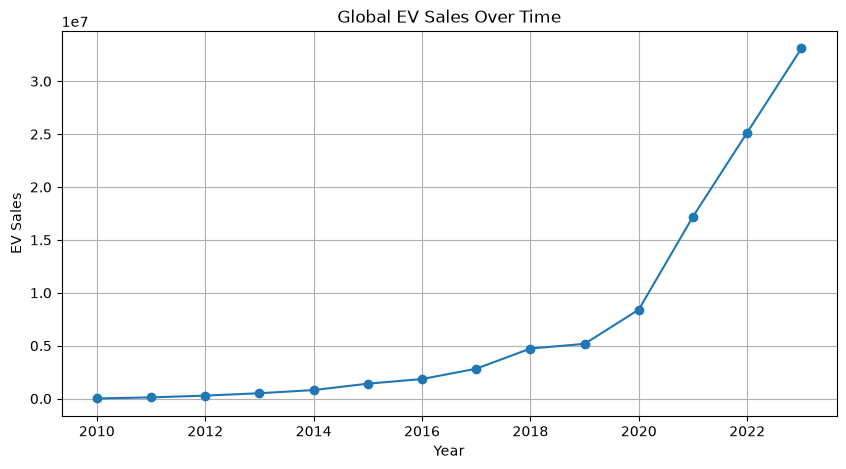

In [54]:
import matplotlib.pyplot as plt

yearly_sales = sales.groupby("year")["value"].sum()
plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title("Global EV Sales Over Time")
plt.xlabel("Year")
plt.ylabel("EV Sales")

plt.grid(True)
plt.savefig("images/ev_sales_global_trend.png")
plt.show()

### Insight

Global EV sales increased steadily between 2010 and 2018 before accelerating rapidly after 2020. This sharp upward trend suggests a significant increase in worldwide EV adoption, reflecting the growing demand for electric vehicles and the expansion of the EV market.

##  Top 10 EV Markets

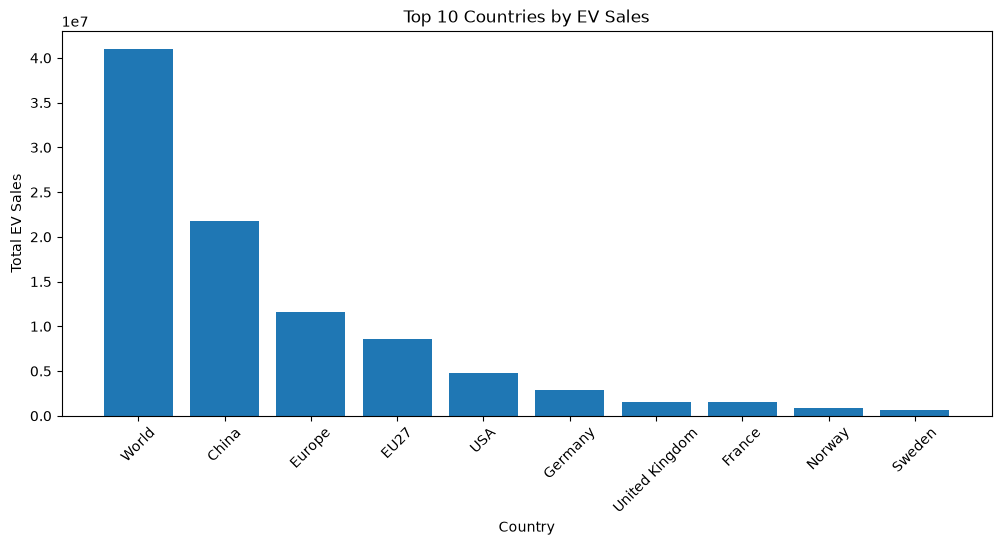

In [53]:
top_countries = sales.groupby("region")["value"].sum().sort_values(ascending=False).head(10)

# Plotting the top 10 countries/regions with the highest total EV sales
plt.figure(figsize=(12,5))
plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by EV Sales")
plt.xlabel("Country")
plt.ylabel("Total EV Sales")

plt.xticks(rotation=45)
plt.savefig("images/ev_sales_top_countries.png")
plt.show()

China is the clear market leader in EV sales, significantly outperforming other individual nations by contributing more than half the volume of total global sales. This dominance highlights a massive concentration of the global electric vehicle market within a single country compared to the rest of the world.

##  BEV vs PHEV vs FCEV

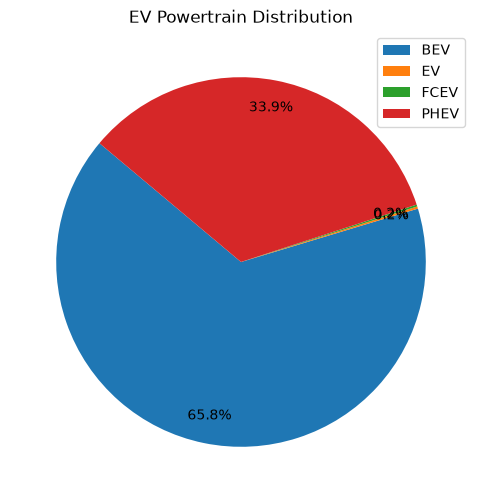

In [52]:
powertrain = df.groupby("powertrain")["value"].sum()

# Create the pie chart
plt.figure(figsize=(8, 6))

# By setting labels=None and adding a legend, we prevent crowding
plt.pie(powertrain.values, 
        autopct='%1.1f%%', 
        pctdistance=0.85, 
        startangle=140)

# Add a title
plt.title("EV Powertrain Distribution")

# Add a legend to clearly list all categories
plt.legend(powertrain.index, loc="best")
plt.savefig("images/ev_powertrain_distribution.png")
plt.show()

Battery Electric Vehicles dominate the EV market compared to other powertrains.

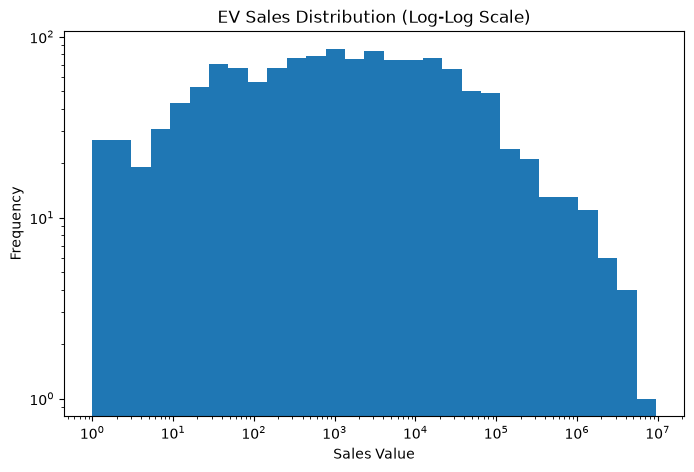

In [51]:
# Logarithmic scale on the x-axis
bins = np.logspace(np.log10(min(sales["value"])), np.log10(max(sales["value"])), 30)

plt.figure(figsize=(8,5))
plt.hist(sales["value"], bins=bins)
plt.xscale('log') # Log scale for the X-axis too, if needed
plt.yscale('log')
plt.title("EV Sales Distribution (Log-Log Scale)")
plt.xlabel("Sales Value")
plt.ylabel("Frequency")
plt.savefig("images/ev_sales_distribution.png")
plt.show()

The EV sales distribution shows that, while sales values span several orders of magnitude, the data is not uniform; instead, it is concentrated around a specific "typical" range. The majority of observations cluster toward the center of the log-scaled range, demonstrating that there is a consistent pattern in sales volume rather than a purely random spread.

### Box Plot of EV Sales Distribution

The box plot provides a summary of the distribution of EV sales values and helps identify potential outliers. It complements the histogram by highlighting the median, interquartile range, and unusually high sales values.

C:\Users\hp\AppData\Local\Temp\ipykernel_26808\3970472447.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(sales["value"], vert=False)


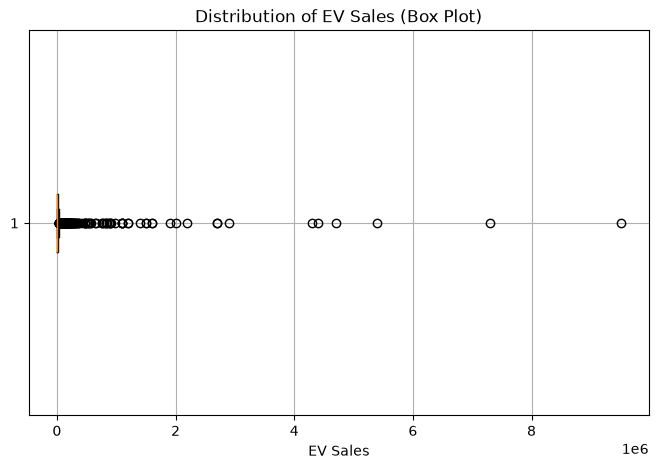

In [84]:
plt.figure(figsize=(8, 5))

plt.boxplot(sales["value"], vert=False)

plt.title("Distribution of EV Sales (Box Plot)")
plt.xlabel("EV Sales")

plt.grid(True)
plt.savefig("images/ev_sales_boxplot.png")
plt.show()

### Insight

The box plot confirms that EV sales are highly right-skewed, with numerous high-value outliers. This indicates that a small number of countries account for exceptionally large EV sales, while most countries record comparatively lower sales.

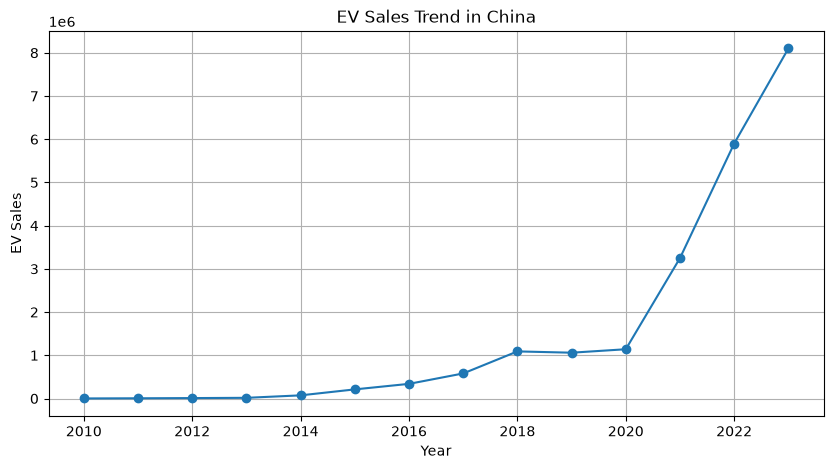

In [50]:
# Country Trend
country_data = sales[sales["region"] == "China"].groupby("year")["value"].sum()

plt.figure(figsize=(10,5))
plt.plot(country_data.index, country_data.values, marker='o')

plt.title("EV Sales Trend in China")
plt.xlabel("Year")
plt.ylabel("EV Sales")
plt.grid(True)
plt.savefig("images/ev_sales_trend_china.png")
plt.show()

### Key Insights of EV Sales Trend in China

- **Rapid Market Expansion:** EV sales in China increased dramatically after 2020, making it the fastest-growing EV market in the dataset.
- **Long-Term Growth:** China progressed from minimal EV adoption in 2010 to several million annual sales by 2023.
- **Acceleration After 2020:** The trend clearly shifts from gradual growth to rapid expansion, highlighting China's leading role in the global EV market.

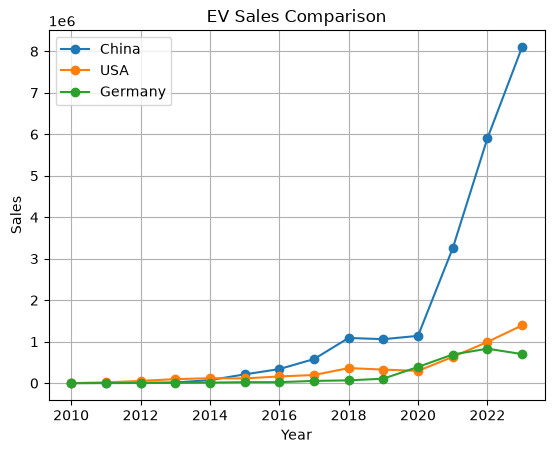

In [49]:
# Multiple Country Comparison
countries = ["China", "USA", "Germany"]

for c in countries:
    data = sales[sales["region"] == c].groupby("year")["value"].sum()
    plt.plot(data.index, data.values, marker='o', label=c)

plt.title("EV Sales Comparison")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("images/ev_sales_trend.png")
plt.show()


### Comparative Analysis of China, the USA, and Germany (2010–2023)

- **China's Market Leadership:** China dominates global EV sales, showing substantially faster growth than both the USA and Germany.
- **Different Growth Patterns:** While all three countries experienced increasing EV adoption, China's growth accelerated much more rapidly after 2020.
- **Widening Adoption Gap:** The gap between China and the other two countries continues to increase, highlighting China's position as the world's largest EV market.

#  Insights and Conclusion

## Key Insights

### 1. EV Sales Growth

The analysis reveals a consistent upward trend in global EV sales throughout the study period, with particularly rapid growth after 2020. This indicates that electric vehicles have transitioned from a niche technology to a rapidly expanding segment of the automotive industry.

### 2. Leading EV Markets

A relatively small number of countries account for most global EV sales. China leads by a substantial margin, while the United States and Germany also contribute significantly, demonstrating that EV adoption remains concentrated in major automotive markets.

### 3. Powertrain Distribution

Battery Electric Vehicles (BEVs) represent the largest share of EV adoption in the dataset, indicating a growing global preference for fully electric vehicles over hybrid alternatives.

### 4. EV Adoption

The analysis shows a steady increase in the market share of electric vehicles over time. This trend indicates that EVs account for an increasing proportion of vehicle sales in many regions during the study period.

### 5. Statistical Analysis

The statistical analysis shows substantial variation in EV sales across different countries and years. The large gap between lower and higher sales values suggests that global EV adoption is highly uneven, with a few regions contributing a significant share of total sales.

In [81]:
print(f"Time Period: {df['year'].min()}–{df['year'].max()}")
print(f"Number of Records: {len(df)}")
print(f"Regions Covered: {df['region'].nunique()}")
print(f"Powertrain Types: {df['powertrain'].nunique()}")

Time Period: 2010–2023
Number of Records: 3798
Regions Covered: 52
Powertrain Types: 4


## Project Summary

| Metric | Summary |
|--------|---------|
| **Dataset** | IEA Historical Electric Vehicle Sales Data |
| **Time Period** | 2010–2023 |
| **Number of Records** | ~3,800 |
| **Regions Covered** | 52 countries/regions |
| **Vehicle Category** | Cars |
| **Powertrain Types** | BEV, PHEV, FCEV, EV |
| **Libraries Used** | Pandas, NumPy, Matplotlib |
| **Main Analyses Performed** | Data Cleaning, Exploratory Data Analysis (EDA), Statistical Analysis, Data Visualization |
| **Key Trend Identified** | Global EV sales increased rapidly, particularly after 2020. |
| **Leading EV Market** | China recorded the highest EV sales in the dataset. |
| **Dominant Powertrain** | Battery Electric Vehicles (BEVs) represented the largest share of EV adoption. |

## Conclusion

This project analyzed historical electric vehicle sales data using Pandas, NumPy, and Matplotlib to explore global EV market trends. Through data exploration, statistical analysis, and visualization, the project identified significant growth in EV adoption, highlighted the leading role of major markets such as China, and demonstrated the dominance of Battery Electric Vehicles (BEVs). Overall, the analysis illustrates the rapid expansion of the global electric vehicle industry and showcases the practical application of Python-based data analysis techniques.

## Skills Demonstrated

- Data loading using Pandas
- Data inspection
- Data cleaning
- Exploratory Data Analysis (EDA)
- GroupBy operations
- Sorting and filtering
- NumPy statistical analysis
- Data visualization using Matplotlib
- Insight generation

## Limitations

- The dataset contains historical data only.
- External factors such as government incentives and fuel prices were not included.
- The analysis focuses on cars and does not cover other vehicle categories.

## Future Improvements

- Add interactive dashboards using Plotly or Power BI.
- Build predictive models to forecast future EV sales.
- Include additional datasets such as charging infrastructure or battery costs.
- Compare EV adoption with fuel vehicle sales.